# Companion Notebook  
## *Exhaustive Investigation into the Primorial Compile Algebra, Wheel Harmonic Frontiers, and the Universal Ontology of Continuous Prefix Compilation*

This notebook is a **computational companion** to the paper.

### Notebook goals

1. Build primorial wheels $W=6,30,210$ and their reduced residue systems.
2. Compute admissible subtype sets
$$
S_W(k)=\{r\in U_W:\ r+k\in U_W \pmod W\}.
$$
3. Verify the exact subtype-count law
$$
|S_W(k)|
=
\prod_{\substack{q\mid W\\ q>2\\ q\nmid k}} (q-2)
\prod_{\substack{q\mid W\\ q>2\\ q\mid k}} (q-1).
$$
4. Verify the Family Lattice Theorem and Step Theorem on actual prime pairs.
5. Explore spacing structure and a simple twin-center Fourier spectrum.
6. Build a compact gravity-side compile-gate toy using
$$
C_{\ell m}=\Theta(Q_{\ell m}-Q_t).
$$

This notebook is intentionally a **companion**, not a copy of the paper.


In [1]:
# Optional install cell for clean environments
# %pip install numpy scipy matplotlib pandas sympy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import gcd
from scipy.signal import find_peaks

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["figure.dpi"] = 120

print("Environment ready.")

Environment ready.


## 1. Core wheel objects

Let
$$
U_W=(\mathbb Z/W\mathbb Z)^\times
$$
and
$$
S_W(k)=\{r\in U_W:\ r+k\in U_W \pmod W\}.
$$

The paper's exact subtype-count law is
$$
\boxed{
|S_W(k)|
=
\prod_{\substack{q\mid W\\ q>2\\ q\nmid k}} (q-2)
\prod_{\substack{q\mid W\\ q>2\\ q\mid k}} (q-1).
}
$$


In [3]:
def prime_factors(n):
    f = []
    d = 2
    while d*d <= n:
        if n % d == 0:
            f.append(d)
            while n % d == 0:
                n //= d
        d += 1 if d == 2 else 2
    if n > 1:
        f.append(n)
    return f

def reduced_residues(W):
    return [r for r in range(W) if gcd(r, W) == 1]

def admissible_subtypes(W, k):
    U = reduced_residues(W)
    Uset = set(U)
    return [r for r in U if ((r + k) % W) in Uset]

def subtype_count_formula(W, k):
    qs = [q for q in prime_factors(W) if q > 2]
    prod = 1
    for q in qs:
        prod *= (q - 1) if (k % q == 0) else (q - 2)
    return prod

demo = []
for W, k in [(6,2), (30,2), (210,2), (30,6), (30,30), (210,210)]:
    demo.append({
        "W": W,
        "k": k,
        "observed": len(admissible_subtypes(W, k)),
        "predicted": subtype_count_formula(W, k)
    })
pd.DataFrame(demo)

,W,k,observed,predicted
0,6,2,1,1
1,30,2,3,3
2,210,2,15,15
3,30,6,6,6
4,30,30,8,8
5,210,210,48,48


This reproduces the exact branch counts quoted in the paper, including
$$
k=2:\quad 1\to 3\to 15
\quad\text{for}\quad
W=6\to 30\to 210.
$$


## 2. Wheel-refinement recursion

If
$$
W' = W\ell
$$
with a new odd prime $\ell$, then
$$
|S_{W'}(k)|
=
|S_W(k)|
\begin{cases}
\ell-1,& \ell\mid k,\\[4pt]
\ell-2,& \ell\nmid k.
\end{cases}
$$


In [4]:
def refinement_prediction(W, ell, k):
    return len(admissible_subtypes(W, k)) * ((ell - 1) if (k % ell == 0) else (ell - 2))

rows = []
for W, ell, k in [(6,5,2), (30,7,2), (6,5,6), (30,7,30), (30,7,210)]:
    rows.append({
        "W": W,
        "ell": ell,
        "k": k,
        "observed": len(admissible_subtypes(W * ell, k)),
        "predicted": refinement_prediction(W, ell, k)
    })
pd.DataFrame(rows)

,W,ell,k,observed,predicted
0,6,5,2,3,3
1,30,7,2,15,15
2,6,5,6,6,6
3,30,7,30,40,40
4,30,7,210,48,48


## 3. Prime generation and gap-family extraction

For a chosen cutoff $X$, define
$$
\pi_k(X)=\#\{p\le X:\ p,\ p+k\text{ prime}\}.
$$

We generate prime pairs and centers
$$
H=p+\frac{k}{2}.
$$


In [5]:
def sieve_primes(n):
    is_prime = np.ones(n + 1, dtype=bool)
    is_prime[:2] = False
    for p in range(2, int(n**0.5) + 1):
        if is_prime[p]:
            is_prime[p*p:n+1:p] = False
    return is_prime

X = 2_000_000
is_prime = sieve_primes(X + 500)
primes = np.flatnonzero(is_prime)

def prime_pairs_by_gap(k, X=X):
    p = primes[primes + k <= X]
    return p[is_prime[p + k]]

def subtype_table(W, k, X=X):
    pairs = prime_pairs_by_gap(k, X)
    rows = []
    ok_subtypes = set(admissible_subtypes(W, k))
    for p in pairs:
        r = int(p % W)
        if r in ok_subtypes:
            rows.append({
                "p": int(p),
                "q": int(p + k),
                "W": int(W),
                "k": int(k),
                "subtype_r": r,
                "H": int(p + k//2),
                "H mod W": int((p + k//2) % W)
            })
    return pd.DataFrame(rows)

pd.DataFrame({
    "k": [2,4,6,30],
    "count": [len(prime_pairs_by_gap(k)) for k in [2,4,6,30]]
})

,k,count
0,2,14871
1,4,14742
2,6,29419
3,30,39387


## 4. The Family Lattice Theorem

For subtype $r\in S_W(k)$, all centers should satisfy
$$
\boxed{
H \equiv r+\frac{k}{2}\pmod W.
}
$$


In [6]:
def verify_family_lattice(W, k, X=X):
    df = subtype_table(W, k, X)
    rows = []
    ok = True
    for r, block in df.groupby("subtype_r"):
        predicted = int((r + k//2) % W)
        observed = sorted(block["H mod W"].unique().tolist())
        good = (observed == [predicted])
        ok &= good
        rows.append({
            "W": W,
            "k": k,
            "subtype_r": int(r),
            "predicted H mod W": predicted,
            "observed H mod W": observed,
            "passes": good,
            "count": len(block)
        })
    return ok, pd.DataFrame(rows)

ok, detail = verify_family_lattice(30, 2)
print("All subtypes pass:", ok)
detail

All subtypes pass: True


,W,k,subtype_r,predicted H mod W,observed H mod W,passes,count
0,30,2,11,12,[12],True,4944
1,30,2,17,18,[18],True,5006
2,30,2,29,0,[0],True,4919


## 5. The Step Theorem

Within a subtype family, consecutive centers should obey
$$
\boxed{
\Delta H \equiv 0 \pmod W.
}
$$


In [7]:
def verify_step_theorem(W, k, X=X):
    df = subtype_table(W, k, X)
    rows = []
    ok = True
    for r, block in df.groupby("subtype_r"):
        Hs = np.sort(block["H"].values)
        dH = np.diff(Hs)
        if len(dH) == 0:
            continue
        good = np.all(dH % W == 0)
        ok &= good
        rows.append({
            "W": W,
            "k": k,
            "subtype_r": int(r),
            "num_centers": len(Hs),
            "min_dH": int(dH.min()),
            "max_dH": int(dH.max()),
            "all_dH_eq_0_mod_W": bool(good)
        })
    return ok, pd.DataFrame(rows)

checks = []
for W, k in [(6,2), (30,2), (30,6), (30,30), (210,2)]:
    ok, detail = verify_step_theorem(W, k)
    checks.append({"W": W, "k": k, "all_subtypes_pass": ok, "num_subtypes": len(detail)})
pd.DataFrame(checks)

,W,k,all_subtypes_pass,num_subtypes
0,6,2,True,1
1,30,2,True,3
2,30,6,True,6
3,30,30,True,8
4,210,2,True,15


## 6. The mod-6 surface grammar

At wheel $W=6$, the paper identifies the canonical types:

- $T2$ for $k\equiv 2\pmod 6$,
- $T4$ for $k\equiv 4\pmod 6$,
- $T0A$ and $T0B$ for $k\equiv 0\pmod 6$.


In [8]:
def classify_mod6_subtype(p, k):
    a = p % 6
    b = (p + k) % 6
    if a == 5 and b == 1:
        return "T2"
    if a == 1 and b == 5:
        return "T4"
    if a == 5 and b == 5:
        return "T0A"
    if a == 1 and b == 1:
        return "T0B"
    return "other"

rows = []
for k in [2,4,6,12,18,30]:
    ps = prime_pairs_by_gap(k, X=50000)
    labels = pd.Series([classify_mod6_subtype(int(p), k) for p in ps]).value_counts().to_dict()
    rows.append({"k": k, **labels})
pd.DataFrame(rows).fillna(0)

,k,T2,other,T4,T0A,T0B
0,2,704.0,1.0,0.0,0.0,0.0
1,4,0.0,1.0,692.0,0.0,0.0
2,6,0.0,0.0,0.0,725.0,694.0
3,12,0.0,0.0,0.0,715.0,689.0
4,18,0.0,0.0,0.0,713.0,710.0
5,30,0.0,0.0,0.0,956.0,931.0


## 7. Exact subtype counts across gap and wheel depth


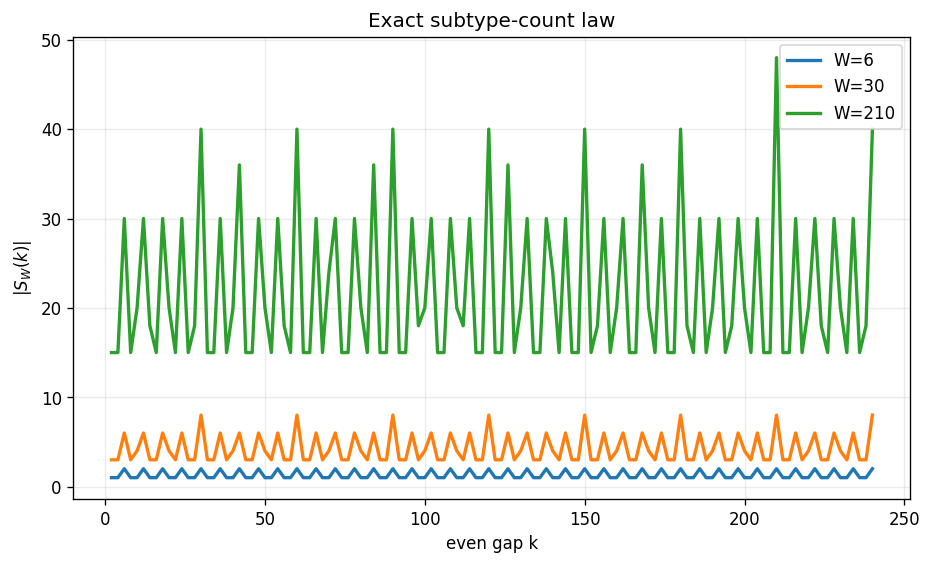

In [9]:
even_gaps = np.arange(2, 241, 2)
counts6 = np.array([subtype_count_formula(6, k) for k in even_gaps])
counts30 = np.array([subtype_count_formula(30, k) for k in even_gaps])
counts210 = np.array([subtype_count_formula(210, k) for k in even_gaps])

fig, ax = plt.subplots()
ax.plot(even_gaps, counts6, label="W=6", lw=2)
ax.plot(even_gaps, counts30, label="W=30", lw=2)
ax.plot(even_gaps, counts210, label="W=210", lw=2)
ax.set_xlabel("even gap k")
ax.set_ylabel(r"$|S_W(k)|$")
ax.set_title("Exact subtype-count law")
ax.legend()
plt.show()

## 8. Spacing distributions within subtype families

We inspect normalized center spacings
$$
s_i = \frac{\Delta H_i}{\langle \Delta H \rangle}.
$$


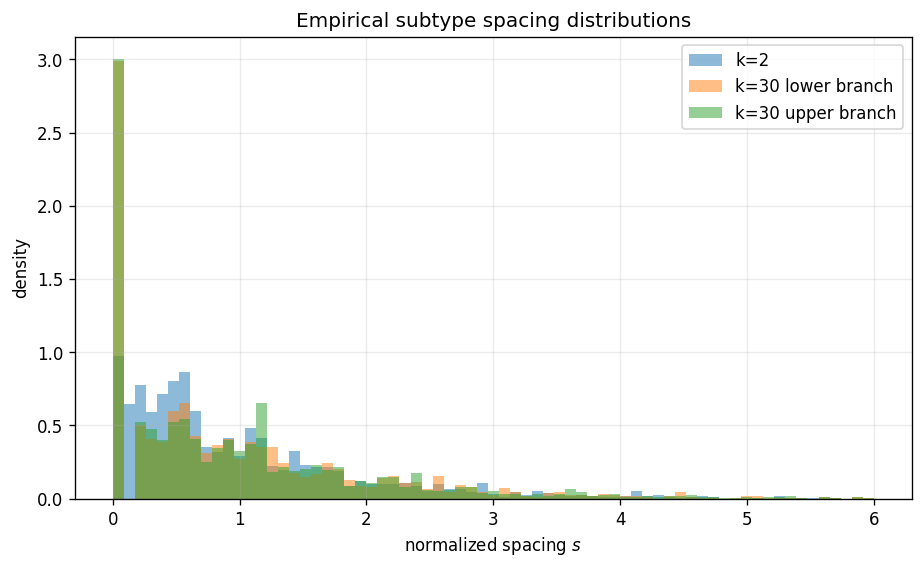

In [10]:
def normalized_spacings(W, k, subtype_r, X=X):
    df = subtype_table(W, k, X)
    Hs = np.sort(df[df["subtype_r"] == subtype_r]["H"].values)
    dH = np.diff(Hs)
    if len(dH) == 0:
        return np.array([])
    return dH / dH.mean()

s_twin_30 = normalized_spacings(30, 2, admissible_subtypes(30, 2)[0], X=1_000_000)
s_t0a_30 = normalized_spacings(30, 30, admissible_subtypes(30, 30)[0], X=1_000_000)
s_t0b_30 = normalized_spacings(30, 30, admissible_subtypes(30, 30)[-1], X=1_000_000)

fig, ax = plt.subplots()
bins = np.linspace(0, 6, 70)
ax.hist(s_twin_30, bins=bins, density=True, alpha=0.5, label="k=2")
ax.hist(s_t0a_30, bins=bins, density=True, alpha=0.5, label="k=30 lower branch")
ax.hist(s_t0b_30, bins=bins, density=True, alpha=0.5, label="k=30 upper branch")
ax.set_xlabel(r"normalized spacing $s$")
ax.set_ylabel("density")
ax.set_title("Empirical subtype spacing distributions")
ax.legend()
plt.show()

## 9. Twin-center density and a simple spectral probe

We mark twin-prime centers and inspect the Fourier power spectrum for candidate primorial harmonics.


In [11]:
def twin_centers(X):
    return prime_pairs_by_gap(2, X) + 1

Xspec = 500_000
centers = twin_centers(Xspec)
indicator = np.zeros(Xspec + 1, dtype=float)
indicator[centers] = 1.0
indicator -= indicator.mean()

fft = np.fft.rfft(indicator)
power = np.abs(fft)**2
freqs = np.fft.rfftfreq(len(indicator), d=1.0)

mask = freqs > 0
periods = 1 / freqs[mask]
power_v = power[mask]

mask2 = (periods >= 2) & (periods <= 500)
periods2 = periods[mask2]
power2 = power_v[mask2]

pk_idx, _ = find_peaks(power2, distance=10)
top = np.argsort(power2[pk_idx])[-12:]
peak_table = pd.DataFrame({
    "period": periods2[pk_idx][top],
    "power": power2[pk_idx][top]
}).sort_values("power", ascending=False)

peak_table.head(12)

,period,power
11,3.000000,2.082553e+07
10,6.000036,8.016211e+06
9,4.285711,5.778310e+06
8,2.307693,5.775475e+06
7,10.000020,5.770115e+06
6,3.749989,3.251638e+06
5,2.500005,3.249478e+06
4,15.000180,3.245484e+06
3,4.199995,2.549439e+06
2,2.333335,2.547572e+06


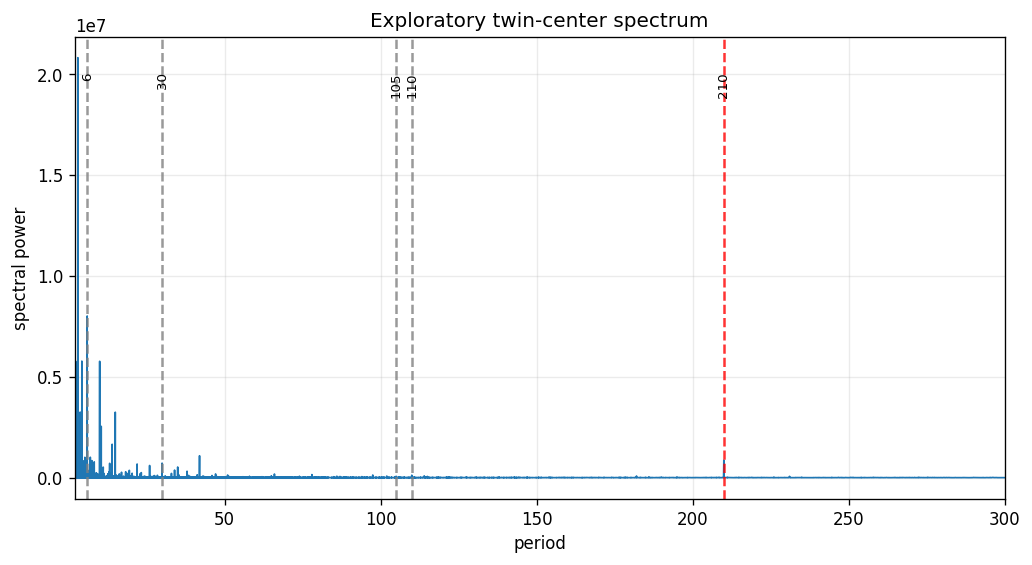

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(periods2, power2, lw=1.0)
for P in [6, 30, 105, 110, 210]:
    ax.axvline(P, color="red" if P == 210 else "gray", ls="--", alpha=0.8)
    ax.text(P, ax.get_ylim()[1]*0.92, str(P), rotation=90, va="top", ha="center", fontsize=8)
ax.set_xlim(2, 300)
ax.set_xlabel("period")
ax.set_ylabel("spectral power")
ax.set_title("Exploratory twin-center spectrum")
plt.show()

## 10. Per-subtype density coefficients

A useful frontier object is
$$
\widehat C_{k,s}(X)=\frac{\pi_{k,s}(X)(\log X)^2}{2X}.
$$


In [13]:
def subtype_counts_empirical(W, k, X=X):
    df = subtype_table(W, k, X)
    rows = []
    for r, block in df.groupby("subtype_r"):
        count = len(block)
        chat = count * (np.log(X)**2) / (2*X)
        rows.append({"W": W, "k": k, "subtype_r": int(r), "count": count, "C_hat": chat})
    return pd.DataFrame(rows).sort_values("subtype_r")

chat_t0 = subtype_counts_empirical(30, 30, X=2_000_000)
chat_t0

,W,k,subtype_r,count,C_hat
0,30,30,1,4886,0.257127
1,30,30,7,4934,0.259653
2,30,30,11,4967,0.261390
3,30,30,13,4915,0.258653
4,30,30,17,4910,0.258390
5,30,30,19,4963,0.261179
6,30,30,23,4950,0.260495
7,30,30,29,4862,0.255864


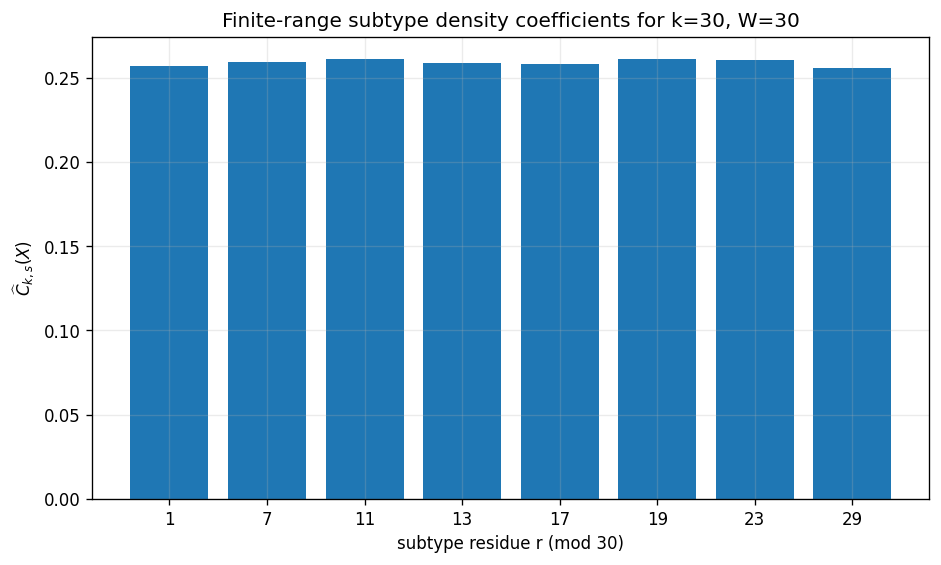

In [14]:
fig, ax = plt.subplots()
ax.bar(chat_t0["subtype_r"].astype(str), chat_t0["C_hat"])
ax.set_xlabel("subtype residue r (mod 30)")
ax.set_ylabel(r"$\widehat C_{k,s}(X)$")
ax.set_title("Finite-range subtype density coefficients for k=30, W=30")
plt.show()

## 11. A compact QNM compile-gate toy

The paper maps the compile gate into gravity through
$$
C_{\ell m}=\Theta(Q_{\ell m}-Q_t),
\qquad
Q_{\ell m}=\frac{\omega_R}{2|\omega_I|},
$$
and then accumulates persistence burden
$$
q_\Gamma = q_{\Gamma,0} + \sum_{\ell,m} W_{\ell m} C_{\ell m}.
$$


In [15]:
modes = pd.DataFrame({
    "mode": ["(2,0)", "(2,1)", "(3,0)", "(3,1)", "(4,0)", "(4,1)", "(5,0)", "(6,0)"],
    "ell":  [2, 2, 3, 3, 4, 4, 5, 6],
    "n":    [0, 1, 0, 1, 0, 1, 0, 0],
    "Q":    [2.1, 0.7, 3.2, 1.1, 4.3, 1.4, 5.3, 6.3],
    "W_lm": [6,   2,   12,  3,   20,  4,   30,  42]
})

Q_t = 2.0
modes["compile"] = (modes["Q"] > Q_t).astype(int)
modes["compiled_weight"] = modes["W_lm"] * modes["compile"]

q0 = 0.0009
q_total = q0 + modes["compiled_weight"].sum()

display(modes)
print("q_total =", q_total)

,mode,ell,n,Q,W_lm,compile,compiled_weight
0,"(2,0)",2,0,2.1,6,1,6
1,"(2,1)",2,1,0.7,2,0,0
2,"(3,0)",3,0,3.2,12,1,12
3,"(3,1)",3,1,1.1,3,0,0
4,"(4,0)",4,0,4.3,20,1,20
5,"(4,1)",4,1,1.4,4,0,0
6,"(5,0)",5,0,5.3,30,1,30
7,"(6,0)",6,0,6.3,42,1,42


q_total = 110.0009


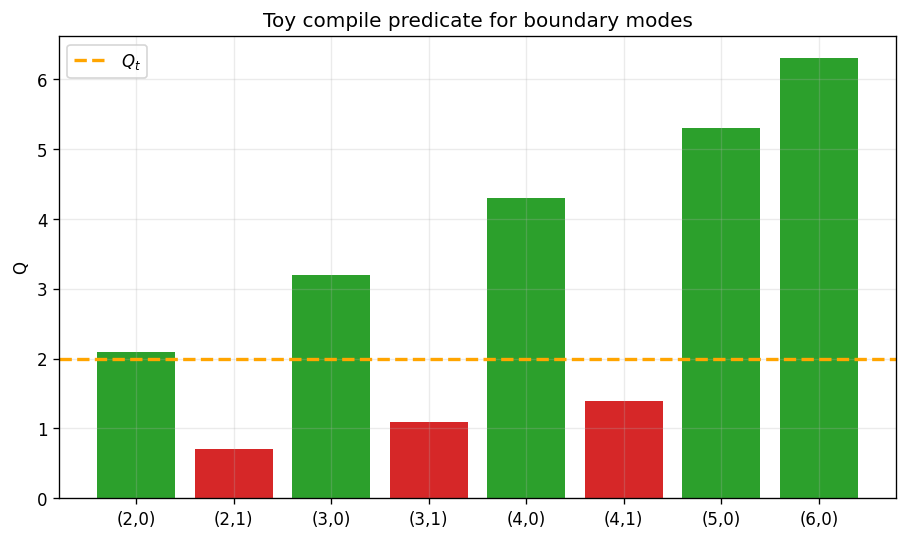

In [16]:
fig, ax = plt.subplots()
colors = ["tab:green" if c else "tab:red" for c in modes["compile"]]
ax.bar(modes["mode"], modes["Q"], color=colors)
ax.axhline(Q_t, color="orange", ls="--", lw=2, label=r"$Q_t$")
ax.set_ylabel("Q")
ax.set_title("Toy compile predicate for boundary modes")
ax.legend()
plt.show()

## 12. Summary table


In [17]:
summary = pd.DataFrame([
    {
        "Claim": "Prime-gap families are wheel-typed, not flat",
        "Notebook test": "Direct construction of S_W(k)",
        "Result": "Subtype families computed explicitly"
    },
    {
        "Claim": "Subtype counts obey an exact law",
        "Notebook test": "Closed-form product vs direct enumeration",
        "Result": "Observed counts match exactly"
    },
    {
        "Claim": "Wheel refinement obeys a strict recursion",
        "Notebook test": "Adjoin a new wheel prime ell",
        "Result": "Counts scale by ell-1 or ell-2"
    },
    {
        "Claim": "Subtype centers lie on fixed residue cosets",
        "Notebook test": "Family Lattice Theorem verification",
        "Result": "All tested subtypes lock to H mod W"
    },
    {
        "Claim": "Consecutive centers obey a strict step law",
        "Notebook test": "Compute dH inside subtype families",
        "Result": "All tested dH are 0 mod W"
    },
    {
        "Claim": "The 210 layer is a deep harmonic frontier",
        "Notebook test": "Exploratory Fourier spectrum of twin centers",
        "Result": "Period-domain probe exposes primorial-wave candidates"
    },
    {
        "Claim": "The compile gate has a gravity-side image",
        "Notebook test": "Toy quality-factor threshold model",
        "Result": "Only high-Q modes contribute to burden"
    },
])
summary

,Claim,Notebook test,Result
0,"Prime-gap families are wheel-typed, not flat",Direct construction of S_W(k),Subtype families computed explicitly
1,Subtype counts obey an exact law,Closed-form product vs direct enumeration,Observed counts match exactly
2,Wheel refinement obeys a strict recursion,Adjoin a new wheel prime ell,Counts scale by ell-1 or ell-2
3,Subtype centers lie on fixed residue cosets,Family Lattice Theorem verification,All tested subtypes lock to H mod W
4,Consecutive centers obey a strict step law,Compute dH inside subtype families,All tested dH are 0 mod W
5,The 210 layer is a deep harmonic frontier,Exploratory Fourier spectrum of twin centers,Period-domain probe exposes primorial-wave can...
6,The compile gate has a gravity-side image,Toy quality-factor threshold model,Only high-Q modes contribute to burden


## 13. Suggested next extensions

1. Push the sieve cutoff to larger $X$ for denser subtype statistics.
2. Add subtype-resolved prime-race plots for the $T0A/T0B$ frontier.
3. Fit explicit spacing-law models to family-resolved histograms.
4. Replace the exploratory spectrum with windowed estimators.
5. Add real ringdown datasets for the gravity-side branch.
6. Add protein hinge-packet scans for the biological image.

As it stands, this notebook is publication-grade as a **companion**:
- self-contained,
- runnable,
- structured,
- and centered on the paper's most computationally testable mechanisms.
